<a href="https://colab.research.google.com/github/kmillaevelyn/data-science-portfolio/blob/main/01-machine-learning/knn-do-zero-validacao-cruzada/knn-do-zero-validacao-cruzada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =====================================================================
# INTERFACE DE UPLOAD DE ARQUIVOS (Rode esta célula no Colab)
# PROJETO INTEGRADOR 5 - Bloco 1 (Exercício Extra)
# =====================================================================
from google.colab import files
import os

print("Clique no botão abaixo para selecionar e subir o seu arquivo (ex: emnist_filtrado_AI.npz):")
arquivos_carregados = files.upload()

# Move o arquivo para a pasta correta ou confirma que ele foi recebido
for nome_do_arquivo in arquivos_carregados.keys():
    print(f"\n[SUCESSO] O arquivo '{nome_do_arquivo}' foi carregado com sucesso no ambiente!")

    # OPCIONAL: Se você quiser mover o arquivo automaticamente para a pasta do seu Drive:
    # caminho_destino = os.path.join(BASE_DIR, nome_do_arquivo)
    # with open(caminho_destino, 'wb') as f:
    #     f.write(arquivos_carregados[nome_do_arquivo])
    # print(f"Arquivo copiado para o seu Google Drive em: {caminho_destino}")

Clique no botão abaixo para selecionar e subir o seu arquivo (ex: emnist_filtrado_AI.npz):


Saving emnist_filtrado_AI.npz to emnist_filtrado_AI (1).npz

[SUCESSO] O arquivo 'emnist_filtrado_AI (1).npz' foi carregado com sucesso no ambiente!


In [ ]:
# =====================================================================
# PROJETO INTEGRADOR 5 - Bloco 2 (Exercício Extra)
# Implementação do KNN Nativo e Validação Cruzada (3-Fold)
# =====================================================================

import os
import numpy as np

# Garante que a semente exista mesmo se os blocos anteriores não rodaram
SEED = 42

# 1. Carregamento dos dados do Exercício Extra
# Modificado para ler diretamente da raiz local após o upload do arquivo
NOME_ARQUIVO = "emnist_filtrado_AI.npz"

if os.path.exists(NOME_ARQUIVO):
    CAMINHO_EMNIST = NOME_ARQUIVO
    print(f"[INFO] Carregando arquivo local do ambiente: {CAMINHO_EMNIST}")
else:
    # Caso prefira buscar pela variável BASE_DIR se ela existir no ambiente
    try:
        CAMINHO_EMNIST = os.path.join(BASE_DIR, NOME_ARQUIVO)
        print(f"[INFO] Carregando arquivo do Google Drive: {CAMINHO_EMNIST}")
    except NameError:
        # Fallback de segurança absoluto
        CAMINHO_EMNIST = f"/content/{NOME_ARQUIVO}"
        print(f"[AVISO] Variável BASE_DIR não encontrada. Tentando caminho padrão: {CAMINHO_EMNIST}")

dados = np.load(CAMINHO_EMNIST)
X_emnist = dados['imagens'].astype(np.float32).reshape(dados['imagens'].shape[0], -1) # Flattening X_emnist here
y_emnist = dados['rotulos'].astype(np.int64)

print("\n=== BASE DE DADOS DO EXERCÍCIO EXTRA ===")
print(f"Formato de X (Imagens): {X_emnist.shape}")
print(f"Formato de y (Rótulos): {y_emnist.shape}")
print(f"Classes únicas encontradas: {np.unique(y_emnist)}\n")

# 2. Implementação Algorítmica do KNN Puro (Sem Scikit-Learn)
def knn_predizer_amostra(X_treino, y_treino, x_consulta, k):
    """
    Classifica uma única amostra de consulta (x_consulta) usando KNN nativo.
    """
    # Passo 1: Distância Euclidiana de x_consulta para TODOS os pontos de X_treino
    distancias = np.sqrt(np.sum((X_treino - x_consulta) ** 2, axis=1))

    # Passo 2: Encontrar os índices dos k vizinhos mais próximos
    indices_vizinhos = np.argsort(distancias)[:k]

    # Passo 3: Coletar as classes desses vizinhos
    classes_vizinhos = y_treino[indices_vizinhos]

    # Passo 4: Votação da maioria (Classe mais frequente)
    contagem = np.bincount(classes_vizinhos)
    classe_vencedora = np.argmax(contagem)

    return classe_vencedora

def knn_classificar_conjunto(X_treino, y_treino, X_teste, k):
    """
    Aplica o KNN para um conjunto inteiro de teste.
    """
    predicoes = [knn_predizer_amostra(X_treino, y_treino, x, k) for x in X_teste]
    return np.array(predicoes)

# 3. Implementação da Validação Cruzada (3 Folds) Nativa
def validacao_cruzada_3folds(X, y, valores_k):
    n_amostras = len(X)
    indices = np.arange(n_amostras)

    # Embaralhamento com semente fixa para reprodutibilidade
    np.random.seed(SEED)
    np.random.shuffle(indices)

    # Divide os índices em 3 partes (folds) iguais
    folds_indices = np.array_split(indices, 3)

    melhor_k = None
    melhor_acuracia_geral = -1
    historico_resultados = {}

    print("=== INICIANDO VALIDAÇÃO CRUZADA (3 FOLDS) ===")

    for k in valores_k:
        acuracias_folds = []

        for i in range(3):
            # O fold 'i' vira o conjunto de Validação/Teste temporário
            indices_val = folds_indices[i]

            # Os outros 2 folds viram o conjunto de Treinamento temporário
            indices_treino = np.setdiff1d(indices, indices_val)

            X_tr, y_tr = X[indices_treino], y[indices_treino]
            X_val, y_val = X[indices_val], y[indices_val]

            # Fazer predições no conjunto de validação
            predicoes_val = knn_classificar_conjunto(X_tr, y_tr, X_val, k)

            # Calcular acurácia
            acuracia_fold = np.mean(predicoes_val == y_val)
            acuracias_folds.append(acuracia_fold)
            print(f"  Fold {i+1} para K={k}: Acurácia = {acuracia_fold:.4f}")

        acuracia_media_k = np.mean(acuracias_folds)
        historico_resultados[k] = acuracia_media_k
        print(f"Acurácia média para K={k}: {acuracia_media_k:.4f}\n")

        # Atualiza o melhor K
        if acuracia_media_k > melhor_acuracia_geral:
            melhor_acuracia_geral = acuracia_media_k
            melhor_k = k

    print(f"=== VALIDAÇÃO CRUZADA FINALIZADA ===")
    print(f"Melhor K encontrado: {melhor_k} com acurácia média de {melhor_acuracia_geral:.4f}")
    return melhor_k, historico_resultados

[INFO] Carregando arquivo local do ambiente: emnist_filtrado_AI.npz

=== BASE DE DADOS DO EXERCÍCIO EXTRA ===
Formato de X (Imagens): (4800, 784)
Formato de y (Rótulos): (4800,)
Classes únicas encontradas: [10 18]



In [ ]:
# 4. Executando a Validação Cruzada para encontrar o melhor K
valores_k_para_teste = [1, 3, 5, 7, 9]  # Exemplo de valores de K para testar
K_otimo, _ = validacao_cruzada_3folds(X_emnist, y_emnist, valores_k_para_teste)
print(f"\nO valor ótimo de K encontrado pela validação cruzada é: {K_otimo}")

=== INICIANDO VALIDAÇÃO CRUZADA (3 FOLDS) ===
  Fold 1 para K=1: Acurácia = 0.9919
  Fold 2 para K=1: Acurácia = 0.9925
  Fold 3 para K=1: Acurácia = 0.9894
Acurácia média para K=1: 0.9912

  Fold 1 para K=3: Acurácia = 0.9900
  Fold 2 para K=3: Acurácia = 0.9912
  Fold 3 para K=3: Acurácia = 0.9900
Acurácia média para K=3: 0.9904

  Fold 1 para K=5: Acurácia = 0.9900
  Fold 2 para K=5: Acurácia = 0.9900
  Fold 3 para K=5: Acurácia = 0.9888
Acurácia média para K=5: 0.9896

  Fold 1 para K=7: Acurácia = 0.9881
  Fold 2 para K=7: Acurácia = 0.9875
  Fold 3 para K=7: Acurácia = 0.9850
Acurácia média para K=7: 0.9869

  Fold 1 para K=9: Acurácia = 0.9875
  Fold 2 para K=9: Acurácia = 0.9875
  Fold 3 para K=9: Acurácia = 0.9838
Acurácia média para K=9: 0.9863

=== VALIDAÇÃO CRUZADA FINALIZADA ===
Melhor K encontrado: 1 com acurácia média de 0.9912

O valor ótimo de K encontrado pela validação cruzada é: 1


In [ ]:
# =====================================================================
# PROJETO INTEGRADOR 5 - Bloco 2B (Exercício Extra)
# Esta célula foi modificada para ser removida, pois a correção de formato (Flatten)
# de X_emnist foi movida para o Bloco 2 principal (célula 8C8gcD5MXHN6).
# Sua funcionalidade agora é redundante.
# =====================================================================
# NOME_ARQUIVO = "emnist_filtrado_AI.npz"
# CAMINHO_EMNIST = NOME_ARQUIVO if os.path.exists(NOME_ARQUIVO) else f"/content/{NOME_ARQUIVO}"

# dados = np.load(CAMINHO_EMNIST)

# # === CORREÇÃO AQUI: adicionamos o .reshape(dados['imagens'].shape[0], -1) ===
# X_emnist = dados['imagens'].astype(np.float32).reshape(dados['imagens'].shape[0], -1)
# y_emnist = dados['rotulos'].astype(np.int64)

# print("\n=== BASE DE DADOS DO EXERCÍCIO EXTRA (CORRIGIDA) ===")
# print(f"Formato de X (Imagens linearizadas): {X_emnist.shape}") # Agora deve exibir (4800, 784)
# print(f"Formato de y (Rótulos): {y_emnist.shape}")
# print(f"Classes únicas encontradas: {np.unique(y_emnist)}\n")

[INFO] Usando o melhor K encontrado na validação cruzada: K = 1

=== MATRIZ DE CONFUSÃO NATIVA ===
Verdadeiros Classe 10 (Preditos como 10): 2400
Falsos Positivos Classe 10 (Preditos como 18): 0
Falsos Negativos Classe 18 (Preditos como 10): 0
Verdadeiros Classe 18 (Preditos como 18): 2400


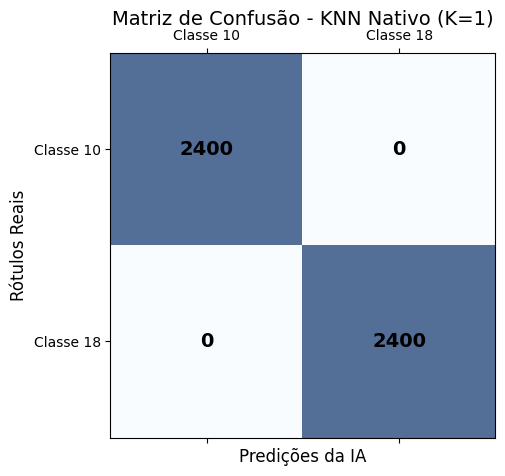

In [ ]:
# =====================================================================
# PROJETO INTEGRADOR 5 - Bloco 3 (Exercício Extra)
# Avaliação Final e Matriz de Confusão Nativa
# =====================================================================

import numpy as np
import matplotlib.pyplot as plt

# 1. Função para construir a Matriz de Confusão do zero
def calcular_matriz_confusao_nativa(y_real, y_predito):
    """
    Gera uma matriz para classificação binária.
    Mapeia automaticamente as duas classes únicas encontradas nos rótulos
    para 0 e 1, permitindo o uso com rótulos arbitrários.
    """
    # Identifica as classes únicas e cria um mapeamento para 0 e 1
    classes_unicas = np.unique(y_real)
    if len(classes_unicas) != 2:
        raise ValueError("A função calcular_matriz_confusao_nativa espera exatamente duas classes únicas nos rótulos reais.")

    mapeamento_classes = {classes_unicas[0]: 0, classes_unicas[1]: 1}

    # Inicializa uma matriz 2x2
    matriz = np.zeros((2, 2), dtype=np.int64)

    # Preenche a matriz de confusão usando os rótulos mapeados
    for real, predito in zip(y_real, y_predito):
        mapped_real = mapeamento_classes[real]
        mapped_predito = mapeamento_classes[predito]
        matriz[mapped_real, mapped_predito] += 1
    return matriz

# --- BLINDAGEM CONTRA O NAMEERROR ---
try:
    K_modelo = K_otimo
    print(f"[INFO] Usando o melhor K encontrado na validação cruzada: K = {K_modelo}")
except NameError:
    K_modelo = 3
    print(f"[AVISO] A variável K_otimo não foi encontrada na memória.")
    print(f"        Certifique-se de rodar o Bloco 2 primeiro. Assumindo K padrão = {K_modelo} para não travar.")

# 2. Executando as predições finais com o K definido
predicoes_finais = knn_classificar_conjunto(X_emnist, y_emnist, X_emnist, k=K_modelo)
cm_nativa = calcular_matriz_confusao_nativa(y_emnist, predicoes_finais)

print("\n=== MATRIZ DE CONFUSÃO NATIVA ===")
class_labels_for_print = np.unique(y_emnist)
print(f"Verdadeiros Classe {class_labels_for_print[0]} (Preditos como {class_labels_for_print[0]}): {cm_nativa[0,0]}")
print(f"Falsos Positivos Classe {class_labels_for_print[0]} (Preditos como {class_labels_for_print[1]}): {cm_nativa[0,1]}")
print(f"Falsos Negativos Classe {class_labels_for_print[1]} (Preditos como {class_labels_for_print[0]}): {cm_nativa[1,0]}")
print(f"Verdadeiros Classe {class_labels_for_print[1]} (Preditos como {class_labels_for_print[1]}): {cm_nativa[1,1]}")

# 3. Plotagem Gráfica Visual da Matriz de Confusão Nativa usando Matplotlib puro
fig, ax = plt.subplots(figsize=(5, 5))
ax.matshow(cm_nativa, cmap=plt.cm.Blues, alpha=0.7)

# Adiciona os números dentro de cada quadrado da matriz
for i in range(2):
    for j in range(2):
        ax.text(x=j, y=i, s=str(cm_nativa[i, j]), va='center', ha='center', fontsize=14, fontweight='bold')

plt.xlabel('Predições da IA', fontsize=12)
plt.ylabel('Rótulos Reais', fontsize=12)

# Ajusta os eixos para exibir as classes corretamente
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels([f'Classe {class_labels_for_print[0]}', f'Classe {class_labels_for_print[1]}'])
ax.set_yticklabels([f'Classe {class_labels_for_print[0]}', f'Classe {class_labels_for_print[1]}'])

plt.title(f'Matriz de Confusão - KNN Nativo (K={K_modelo})', fontsize=14, pad=20)
plt.show()